In [2]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

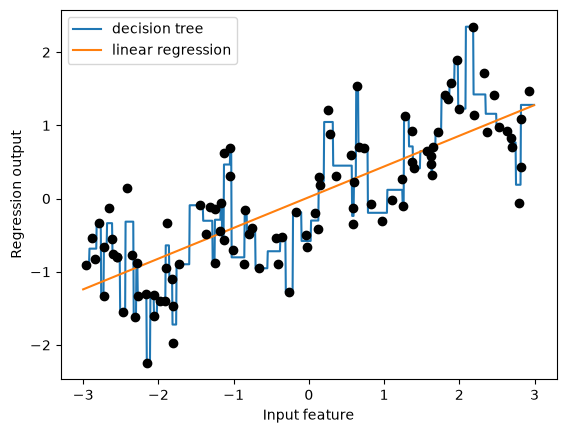

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X, y = mglearn.datasets.make_wave(n_samples=100)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)

reg = DecisionTreeRegressor(min_samples_split=3).fit(X, y)
plt.plot(line, reg.predict(line), label="decision tree")

reg = LinearRegression().fit(X, y)
plt.plot(line, reg.predict(line), label="linear regression")

plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")
plt.show()

In [ ]:
#ビニング

#np.linspaceを使って、-3から3までの範囲を10等分する境界値を作る
bins = np.linspace(-3,3,11)
print("bins:",bins)

bins: [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]


In [ ]:
#個々のデータポイントがどのビンに入るかを記録する
#np.digitizeを使って簡単にできる

#これにより連続値の特徴量を離散的な特徴量に変換することができる

which_bin = np.digitize(X,bins=bins)
print("\nData points:\n",X[:5])
print("\nBin membership for data points:\n",which_bin[:5])


Data points:
 [[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]

Bin membership for data points:
 [[ 4]
 [10]
 [ 8]
 [ 6]
 [ 2]]


In [7]:
from sklearn.preprocessing import OneHotEncoder

#デフォルトだと、OneHotEncoderは疎行列を返すので、sparse=Falseを指定して密行列を返すようにする
encoder = OneHotEncoder(sparse_output=False)

#encoder.fitでwhich_binに現れる整数値バージョンを確認
encoder.fit(which_bin)

#transformで、ワンホットエンコーディングを実行
X_binned = encoder.transform(which_bin)
print(X_binned[:5])

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
#十個のビンに分けたので、10個の特徴量に変換されている
print("\nX_binned.shape:",X_binned.shape)


X_binned.shape: (100, 10)


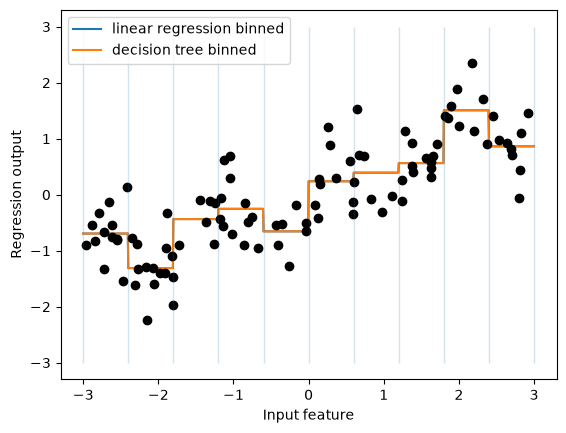

In [10]:
line_binned = encoder.transform(np.digitize(line, bins=bins))

reg = LinearRegression().fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label='linear regression binned')

reg = DecisionTreeRegressor(min_samples_split=3).fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label='decision tree binned')
plt.plot(X[:, 0], y, 'o', c='k')
plt.vlines(bins, -3, 3, linewidth=1, alpha=.2)
plt.legend(loc="best")
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.show()